# Task 1 & 2: Add metrics function and Ridge regularization to the LogisticRegression class

In [143]:
import itertools
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mlflow import MlflowClient
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler


In [144]:
def data_cleaning(input_df: pd.DataFrame) -> pd.DataFrame:
    df = input_df.copy()

    # Drop unused columns first to reduce size
    df = df.drop(columns=["torque"])

    # Drop rows that will definitely not be used
    df = df[~df["fuel"].isin(["CNG", "LPG"])]
    df = df[df["owner"] != "Test Drive Car"]

    # Remove Units
    df["mileage"] = df["mileage"].str.split(" ").str[0]
    df["engine"] = df["engine"].str.split(" ").str[0]
    df["max_power"] = df["max_power"].str.split(" ").str[0]

    # Numeric Type conversion
    df["mileage"] = df["mileage"].astype(float)
    df["engine"] = df["engine"].astype(float)
    df["max_power"] = df["max_power"].astype(float)

    # Fix Brand column
    df = df.rename(columns={"name": "brand"})
    df["brand"] = df["brand"].str.split(" ").str[0]

    return df


In [145]:
# This function was added to utils folder for easy workflow during the assignment period
# But I paste it here so that it shows up in the file for submission


def get_preprocessor() -> ColumnTransformer:
    # Define transformers for each feature group
    brand_le = (
        "brand_le",
        Pipeline(
            [
                # Pre-imputer for handling missing values before encoding
                ("pre_imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan)),
                ("post_imputer", SimpleImputer(strategy="most_frequent")),
                # Post-imputer for handling any NaN introduced by unknown categories during encoding
                # So the pipeline is robust to unseen categories in production data
                # This won't happen if frontend limits the choices to existing categories only
                # But it's better to be safe than sorry
            ],
        ),
        ["brand"],
    )

    fuel_le = (
        "fuel_le",
        Pipeline(
            [
                ("pre_imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan)),
                ("post_imputer", SimpleImputer(strategy="most_frequent")),
            ],
        ),
        ["fuel"],
    )

    transmission_le = (
        "transmission_le",
        Pipeline(
            [
                ("pre_imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan)),
                ("post_imputer", SimpleImputer(strategy="most_frequent")),
            ],
        ),
        ["transmission"],
    )

    owner_le = (
        "owner_le",
        Pipeline(
            [
                ("pre_imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OrdinalEncoder(
                        categories=[
                            [
                                "First Owner",
                                "Second Owner",
                                "Third Owner",
                                "Fourth & Above Owner",
                            ],
                        ],
                        handle_unknown="use_encoded_value",
                        unknown_value=np.nan,
                    ),
                ),
                ("post_imputer", SimpleImputer(strategy="most_frequent")),
            ],
        ),
        ["owner"],
    )

    seller_type_ohe = (
        "seller_type_ohe",
        Pipeline(
            [
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")),
            ],
        ),
        ["seller_type"],
    )

    pipeline_steps = [
        (
            "imputer",
            ColumnTransformer(
                transformers=[
                    ("year_imputer", SimpleImputer(strategy="median"), ["year"]),
                    ("km_imputer", SimpleImputer(strategy="median"), ["km_driven"]),
                    ("mileage_imputer", SimpleImputer(strategy="mean"), ["mileage"]),
                    ("engine_imputer", SimpleImputer(strategy="median"), ["engine"]),
                    ("max_power_imputer", SimpleImputer(strategy="median"), ["max_power"]),
                    ("seats_imputer", SimpleImputer(strategy="most_frequent"), ["seats"]),
                ],
                remainder="passthrough",
            ),
        ),
        ("scaler", StandardScaler()),
    ]

    num_scaler = (
        "num_scaler",
        Pipeline(pipeline_steps),
        ["year", "km_driven", "mileage", "engine", "max_power", "seats"],
    )

    # Combine all transformers into the ColumnTransformer
    return ColumnTransformer(
        transformers=[
            brand_le,
            fuel_le,
            transmission_le,
            owner_le,
            seller_type_ohe,
            num_scaler,
        ],
        remainder="passthrough",
        verbose_feature_names_out=True,
    )


In [146]:
# Load, Clean, Split, Preprocess Data
df = pd.read_csv("Cars.csv")
df_train, df_test = train_test_split(df, random_state=42, test_size=0.2)
df_train = data_cleaning(df_train)
df_test = data_cleaning(df_test)
X_train = df_train.drop(columns=["selling_price"])
X_test = df_test.drop(columns=["selling_price"])
y_train = df_train["selling_price"]
y_test = df_test["selling_price"]
preprocessor = get_preprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [147]:
X_train_processed

array([[28.        ,  1.        ,  0.        , ..., -0.52164143,
        -0.22173147, -0.43052056],
       [10.        ,  1.        ,  1.        , ..., -0.52364492,
        -0.13723679, -0.43052056],
       [11.        ,  0.        ,  1.        , ..., -0.12695496,
        -0.0468077 , -0.43052056],
       ...,
       [11.        ,  1.        ,  1.        , ..., -0.5256484 ,
        -0.27768447, -0.43052056],
       [20.        ,  0.        ,  1.        , ..., -0.42347069,
        -0.49838797, -0.43052056],
       [20.        ,  1.        ,  1.        , ..., -1.32904574,
        -1.54453951, -1.48361487]], shape=(6421, 12))

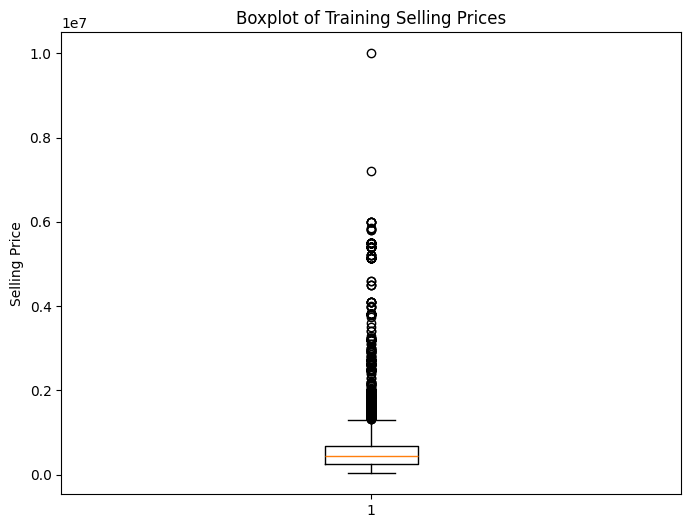

In [148]:
plt.figure(figsize=(8, 6))
plt.boxplot(y_train)
plt.title("Boxplot of Training Selling Prices")
plt.ylabel("Selling Price")
plt.show()

In [149]:
q1 = y_train.quantile(0.25)
q2 = y_train.quantile(0.5)
q3 = y_train.quantile(0.75)
print(f"Q1: {q1}, Q2: {q2}, Q3: {q3}")

Q1: 260000.0, Q2: 450000.0, Q3: 685000.0


In [ ]:
y_train_class = pd.cut(
    y_train,
    bins=[-1, q1, q2, q3, np.inf],
    labels=[0, 1, 2, 3],
)
y_test = pd.cut(
    y_test,
    bins=[-1, q1, q2, q3, np.inf],
    labels=[0, 1, 2, 3],
)

In [151]:
y_train_class.value_counts()

selling_price
0    1638
1    1616
3    1603
2    1564
Name: count, dtype: int64

In [152]:
# check if the class bin is correct
y_train_class.value_counts()

selling_price
0    1638
1    1616
3    1603
2    1564
Name: count, dtype: int64

In [153]:
y_train_class

6518    2
6144    1
6381    1
438     2
5939    1
       ..
5226    2
5390    2
860     2
7603    3
7270    0
Name: selling_price, Length: 6421, dtype: category
Categories (4, int64): [0 < 1 < 2 < 3]

In [154]:
class LogisticRegression:
    def __init__(
        self,
        train_method: str,
        alpha: float,
        max_iter: int,
    ) -> None:
        self.alpha = alpha
        self.max_iter = max_iter
        self.train_method = train_method

    def fit(self, X: np.ndarray, Y: np.ndarray) -> None:
        # Initialize weights randomly
        X_intercept = self.add_intercept(X)
        Y = self.to_one_hot(Y)
        self.n = X_intercept.shape[1]
        self.k = Y.shape[1]
        self.W = np.random.rand(self.n, self.k)
        self.losses = []

        if self.train_method == "batch":
            self.batch_gradient(X_intercept, Y)
        elif self.train_method == "mini-batch":
            self.minibatch_gradient(X_intercept, Y)
        elif self.train_method == "stochastic":
            self.stochastic_gradient(X_intercept, Y)
        else:
            msg = (
                'Method must be one of the followings: "batch", "mini-batch" or "stochastic". '
                "The provided method was + self.train_method"
            )
            raise ValueError(msg)

    def batch_gradient(self, X: np.ndarray, Y: np.ndarray) -> tuple[float, np.ndarray]:
        start_time = time.time()
        for i in range(self.max_iter):
            loss, grad = self.gradient(X, Y)
            self.losses.append(loss)
            self.W = self.W - self.alpha * grad
            if i % 500 == 0:
                print(f"Loss at iteration {i}", loss)
        print(f"time taken: {time.time() - start_time}")

    def minibatch_gradient(self, X: np.ndarray, Y: np.ndarray) -> None:
        start_time = time.time()
        batch_size = int(0.1 * X.shape[0])
        for i in range(self.max_iter):
            # This implementation of random with replacement is not that good
            # because it just random one starting index and take the next batch_size samples
            # ix = np.random.randint(0, X.shape[0])  # <----with replacement
            # batch_X = X[ix : ix + batch_size]
            # batch_Y = Y[ix : ix + batch_size]

            # This is a better implementation of random with replacement with true randomness
            # with every time I sample a batch, I can get any sample from the dataset
            batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=True)
            batch_X = X[batch_indices]
            batch_Y = Y[batch_indices]

            loss, grad = self.gradient(batch_X, batch_Y)
            self.losses.append(loss)
            self.W = self.W - self.alpha * grad
            if i % 500 == 0:
                print(f"Loss at iteration {i}", loss)
        print(f"time taken: {time.time() - start_time}")

    def stochastic_gradient(self, X: np.ndarray, Y: np.ndarray) -> None:
        start_time = time.time()
        for i in range(self.max_iter):
            # Randomly pick one sample with replacement
            idx = np.random.randint(X.shape[0])
            X_train = X[idx, :].reshape(1, -1)
            Y_train = Y[idx]
            loss, grad = self.gradient(X_train, Y_train)
            self.losses.append(loss)
            self.W = self.W - self.alpha * grad
            if i % 500 == 0:
                print(f"Loss at iteration {i}", loss)
        print(f"time taken: {time.time() - start_time}")

    def gradient(self, X: np.ndarray, Y: np.ndarray) -> tuple[float, np.ndarray]:
        Y_hat = self.h_theta(X, self.W)
        loss = self.cross_entropy(Y, Y_hat)
        grad = X.T @ (Y_hat - Y) / Y.shape[0]
        return loss, grad

    def cross_entropy(self, Y: np.ndarray, Y_hat: np.ndarray) -> float:
        m = Y.shape[0]
        return -np.sum(Y * np.log(Y_hat)) / m

    def softmax(self, theta_t_x: np.ndarray) -> np.ndarray:
        return np.exp(theta_t_x) / np.sum(np.exp(theta_t_x), axis=1, keepdims=True)

    def add_intercept(self, X: np.ndarray) -> np.ndarray:
        intercept = np.ones((X.shape[0], 1))
        return np.hstack((intercept, X))

    def to_one_hot(self, Y: np.ndarray) -> np.ndarray:
        oh_mapping = {
            "0": [1, 0, 0, 0],
            "1": [0, 1, 0, 0],
            "2": [0, 0, 1, 0],
            "3": [0, 0, 0, 1],
        }
        return np.array([oh_mapping[str(label)] for label in Y])

    def h_theta(self, X: np.ndarray, W: np.ndarray) -> np.ndarray:
        """
        Input:
            X shape: (m, n)
            w shape: (n, k)
        Returns:
            yhat shape: (m, k)
        """
        return self.softmax(X @ W)

    def predict(self, X_test: np.ndarray) -> np.ndarray:
        X_test_intercept = self.add_intercept(X_test)
        probabilities = self.h_theta(X_test_intercept, self.W)
        return np.argmax(probabilities, axis=1)

    def predict_proba(self, X_test: np.ndarray) -> np.ndarray:
        """Return probabilities for compatibility"""
        X_test_intercept = self.add_intercept(X_test)
        return self.h_theta(X_test_intercept, self.W)

    def plot(self) -> None:
        plt.plot(np.arange(len(self.losses)), self.losses, label="Train Losses")
        plt.title("Losses")
        plt.xlabel("epoch")
        plt.ylabel("losses")
        plt.legend()

    def true_positives(self, y_true: np.ndarray, y_pred: np.ndarray, label: int) -> int:
        return np.sum((y_true == label) & (y_pred == label))

    def true_negatives(self, y_true: np.ndarray, y_pred: np.ndarray, label: int) -> int:
        return np.sum((y_true != label) & (y_pred != label))

    def false_positives(self, y_true: np.ndarray, y_pred: np.ndarray, label: int) -> int:
        return np.sum((y_true != label) & (y_pred == label))

    def false_negatives(self, y_true: np.ndarray, y_pred: np.ndarray, label: int) -> int:
        return np.sum((y_true == label) & (y_pred != label))

    def accuracy(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        return np.mean(y_true == y_pred)

    def precision(self, y_true: np.ndarray, y_pred: np.ndarray, label: int) -> float:
        tp = self.true_positives(y_true, y_pred, label)
        fp = self.false_positives(y_true, y_pred, label)
        if (tp + fp) == 0:
            return 0.0
        return tp / (tp + fp)

    def recall(self, y_true: np.ndarray, y_pred: np.ndarray, label: int) -> float:
        tp = self.true_positives(y_true, y_pred, label)
        fn = self.false_negatives(y_true, y_pred, label)
        if (tp + fn) == 0:
            return 0.0
        return tp / (tp + fn)

    def f1_score(self, y_true: np.ndarray, y_pred: np.ndarray, label: int) -> float:
        precision = self.precision(y_true, y_pred, label)
        recall = self.recall(y_true, y_pred, label)
        if (precision + recall) == 0:
            return 0.0
        return 2 * (precision * recall) / (precision + recall)

    def macro_precision(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        labels = np.unique(y_true)
        precisions = [self.precision(y_true, y_pred, label) for label in labels]
        return np.mean(precisions)

    def macro_recall(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        labels = np.unique(y_true)
        recalls = [self.recall(y_true, y_pred, label) for label in labels]
        return np.mean(recalls)

    def macro_f1_score(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        labels = np.unique(y_true)
        f1s = [self.f1_score(y_true, y_pred, label) for label in labels]
        return np.mean(f1s)

    def weighted_precision(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        labels, counts = np.unique(y_true, return_counts=True)
        precisions = [self.precision(y_true, y_pred, label) for label in labels]
        weighted_precisions = [p * c for p, c in zip(precisions, counts, strict=False)]
        return np.sum(weighted_precisions) / np.sum(counts)

    def weighted_recall(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        labels, counts = np.unique(y_true, return_counts=True)
        recalls = [self.recall(y_true, y_pred, label) for label in labels]
        weighted_recalls = [r * c for r, c in zip(recalls, counts, strict=False)]
        return np.sum(weighted_recalls) / np.sum(counts)

    def weighted_f1_score(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        labels, counts = np.unique(y_true, return_counts=True)
        f1s = [self.f1_score(y_true, y_pred, label) for label in labels]
        weighted_f1s = [f1 * c for f1, c in zip(f1s, counts, strict=False)]
        return np.sum(weighted_f1s) / np.sum(counts)

    def classification_report(self, y_true: np.ndarray, y_pred: np.ndarray) -> None:
        labels = np.unique(y_true)
        # Print classification report in markdown table format
        header = "| Label | Precision | Recall | F1-Score |\n|-------|-----------|--------|----------|"
        print(header)
        for label in labels:
            precision = self.precision(y_true, y_pred, label)
            recall = self.recall(y_true, y_pred, label)
            f1 = self.f1_score(y_true, y_pred, label)
            print(f"| {label} | {precision:.4f} | {recall:.4f} | {f1:.4f} |")
        print(
            f"| Macro Avg | {self.macro_precision(y_true, y_pred):.4f} | "
            f"{self.macro_recall(y_true, y_pred):.4f} | "
            f"{self.macro_f1_score(y_true, y_pred):.4f} |",
        )
        print(
            f"| Weighted Avg | {self.weighted_precision(y_true, y_pred):.4f} | "
            f"{self.weighted_recall(y_true, y_pred):.4f} | "
            f"{self.weighted_f1_score(y_true, y_pred):.4f} |",
        )
        print(f"\n**Overall Accuracy:** {self.accuracy(y_true, y_pred):.4f}")


class RidgePenalty:
    def __init__(self, l: np.ndarray) -> None:
        self.l = l

    def __call__(self, theta: np.ndarray) -> np.ndarray:
        return self.l * np.sum(np.square(theta[1:]))  # do not regularize bias term

    def derivation(self, theta: np.ndarray) -> np.ndarray:
        g = np.zeros_like(theta)
        g[1:] = self.l * 2 * (theta[1:])  # do not regularize bias term
        return g


class RidgeLogisticRegression(LogisticRegression):
    def __init__(
        self,
        train_method: str,
        alpha: float,
        max_iter: int,
        l: float = 0.1,
    ) -> None:
        super().__init__(train_method, alpha, max_iter)
        self.penalty = RidgePenalty(l)

    def gradient(self, X: np.ndarray, Y: np.ndarray) -> tuple[float, np.ndarray]:
        m = X.shape[0]
        Y_hat = self.h_theta(X, self.W)
        loss = -np.sum(Y * np.log(Y_hat)) / m + self.penalty(self.W) / m
        grad = X.T @ (Y_hat - Y) + self.penalty.derivation(self.W) / m
        return loss, grad

In [155]:
k = len(y_train_class.unique())
m = X_train_processed.shape[1]
model = LogisticRegression("batch", 0.001, 5000)


In [156]:
model.fit(X_train_processed, y_train_class)
y_pred = model.predict(X_test_processed)
y_pred

Loss at iteration 0 5.655268114893226
Loss at iteration 500 1.379968447899385
Loss at iteration 1000 1.2618215544744167
Loss at iteration 1500 1.1811674674008446
Loss at iteration 2000 1.1228926536952164
Loss at iteration 2500 1.0787105590335992
Loss at iteration 3000 1.0439237813927162
Loss at iteration 3500 1.0157184929547955
Loss at iteration 4000 0.9923148142104398
Loss at iteration 4500 0.9725375068210117
time taken: 2.263841390609741


array([0, 2, 2, ..., 0, 1, 0], shape=(1607,))

In [157]:
y_pred

array([0, 2, 2, ..., 0, 1, 0], shape=(1607,))

In [ ]:
model.classification_report(y_test, y_pred)

| Label | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| 0 | 0.6648 | 0.8471 | 0.7449 |
| 1 | 0.4330 | 0.3621 | 0.3944 |
| 2 | 0.4519 | 0.4367 | 0.4442 |
| 3 | 0.6886 | 0.6342 | 0.6603 |
| Macro Avg | 0.5595 | 0.5700 | 0.5609 |
| Weighted Avg | 0.5574 | 0.5688 | 0.5591 |

**Overall Accuracy:** 0.5688


=========Classification report=======
              precision    recall  f1-score   support

           0       0.66      0.85      0.74       412
           1       0.43      0.36      0.39       428
           2       0.45      0.44      0.44       387
           3       0.69      0.63      0.66       380

    accuracy                           0.57      1607
   macro avg       0.56      0.57      0.56      1607
weighted avg       0.56      0.57      0.56      1607



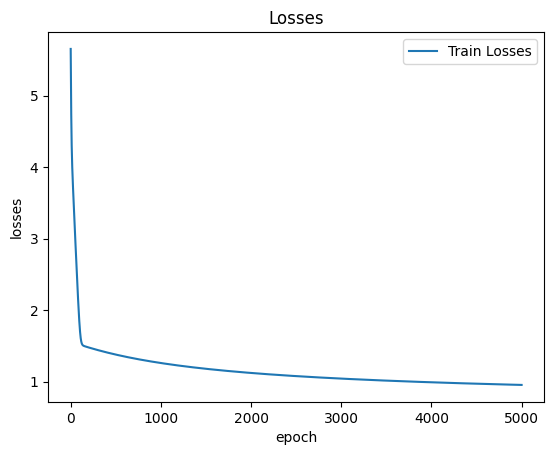

In [ ]:
model.plot()
print("=========Classification report=======")
print(classification_report(y_test, y_pred))

What does support in the classification report means?
- Support is a number of samples the respective class

# Task 3: Deployment

In [160]:
import mlflow

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("st125923-a3")

<Experiment: artifact_location='mlflow-artifacts:/106080689717494394', creation_time=1759578450997, experiment_id='106080689717494394', last_update_time=1759578450997, lifecycle_stage='active', name='st125923-a3', tags={}>

In [161]:
model_types = ["Normal", "Ridge"]
train_methods = ["batch", "mini-batch", "stochastic"]
learning_rates = [0.01, 0.001, 0.0001]

all_combinations = list(
    itertools.product(
        model_types,
        train_methods,
        learning_rates,
    ),
)
keys = ["model_type", "train_method", "learning_rate"]
params_combinations = [dict(zip(keys, comb, strict=False)) for comb in all_combinations]
len(params_combinations)

18

In [162]:
params_combinations[0]

{'model_type': 'Normal', 'train_method': 'batch', 'learning_rate': 0.01}

In [1]:
def start_experiment(
    X_train_original: pd.DataFrame,
    y_train_original: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    params_combinations: list[dict],
    max_iter: int = 5000,
) -> dict:
    models = {}
    for i, params in enumerate(params_combinations):
        log_string = f"Reg-{params['model_type']}_TrainMethod-{params['train_method']}_LR-{params['learning_rate']}"
        mlflow.start_run(run_name=log_string)
        mlflow.log_params(params)

        print("=============== Experiment: ", i + 1, " / ", len(params_combinations), "===============")
        print(log_string)

        if params["model_type"] == "Normal":
            model = LogisticRegression(
                train_method=params["train_method"],
                alpha=params["learning_rate"],
                max_iter=max_iter,
            )
        elif params["model_type"] == "Ridge":
            model = RidgeLogisticRegression(
                train_method=params["train_method"],
                alpha=params["learning_rate"],
                max_iter=max_iter,
                l=0.1,
            )
        else:
            print("Error: Please select correct model type.")
            break

        pipeline = Pipeline(
            steps=[
                ("preprocess", get_preprocessor()),
                ("model", model),
            ],
        )

        # After adding all the steps, fit the pipeline
        # The reason to fit the whole pipeline here instead of just the model
        # is to ensure that the shape of X after preprocessing will match the input of model
        # so that during prediction, I can just call pipeline.predict(X) directly
        # using the original X_train without any preprocessing
        # which will be useful during inference in production where input data is raw but human-readable
        pipeline.fit(X_train_original, y_train_original)

        models[log_string] = pipeline

        y_pred = pipeline.predict(X_test)

        # Get model from pipeline
        # (last step so index = -1)
        # and it's a tuple of (name, model) so get the model with [1]
        fitted_model = pipeline.steps[-1][1]

        pipeline.steps[-1][1].classification_report(y_test, y_pred)

        mlflow.log_metrics(
            metrics={
                "accuracy": fitted_model.accuracy(y_test, y_pred),
                "class_0_precision": fitted_model.precision(y_test, y_pred, 0),
                "class_0_recall": fitted_model.recall(y_test, y_pred, 0),
                "class_0_f1": fitted_model.f1_score(y_test, y_pred, 0),
                "class_1_precision": fitted_model.precision(y_test, y_pred, 1),
                "class_1_recall": fitted_model.recall(y_test, y_pred, 1),
                "class_1_f1": fitted_model.f1_score(y_test, y_pred, 1),
                "class_2_precision": fitted_model.precision(y_test, y_pred, 2),
                "class_2_recall": fitted_model.recall(y_test, y_pred, 2),
                "class_2_f1": fitted_model.f1_score(y_test, y_pred, 2),
                "class_3_precision": fitted_model.precision(y_test, y_pred, 3),
                "class_3_recall": fitted_model.recall(y_test, y_pred, 3),
                "class_3_f1": fitted_model.f1_score(y_test, y_pred, 3),
                "macro_precision": fitted_model.macro_precision(y_test, y_pred),
                "macro_recall": fitted_model.macro_recall(y_test, y_pred),
                "macro_f1": fitted_model.macro_f1_score(y_test, y_pred),
                "weighted_precision": fitted_model.weighted_precision(y_test, y_pred),
                "weighted_recall": fitted_model.weighted_recall(y_test, y_pred),
                "weighted_f1": fitted_model.weighted_f1_score(y_test, y_pred),
            },
        )

        # Below this is the old code provided in Regularization.ipynb
        # which saves only the last fold model which is not correct
        # I will refit the model with the best params and save the model later
        signature = mlflow.models.infer_signature(X_train_original, pipeline.predict(X_train_original))
        mlflow.sklearn.log_model(pipeline, name="model", signature=signature)
        mlflow.end_run()
    return models

NameError: name 'pd' is not defined

In [175]:
# suppress overflow warnings for log
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    models = start_experiment(
        X_train,
        y_train_class,
        params_combinations=params_combinations,
        max_iter=5000,
    )

=============== Experiment:  1  /  18 ===============
Reg-Normal_TrainMethod-batch_LR-0.01
Loss at iteration 0 4.6332700286095925
Loss at iteration 500 0.958607490972343
Loss at iteration 1000 0.8609519489499131
Loss at iteration 1500 0.8149978272997009
Loss at iteration 2000 0.7870585881807101
Loss at iteration 2500 0.7678702302660712
Loss at iteration 3000 0.7537162825038916
Loss at iteration 3500 0.7427731995701032
Loss at iteration 4000 0.7340255231537028
Loss at iteration 4500 0.726856114461377
time taken: 2.2561445236206055
| Label | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| 0 | 0.8116 | 0.8155 | 0.8136 |
| 1 | 0.5657 | 0.5631 | 0.5644 |
| 2 | 0.5126 | 0.5271 | 0.5197 |
| 3 | 0.7724 | 0.7500 | 0.7610 |
| Macro Avg | 0.6656 | 0.6639 | 0.6647 |
| Weighted Avg | 0.6648 | 0.6633 | 0.6640 |

**Overall Accuracy:** 0.6633
🏃 View run Reg-Normal_TrainMethod-batch_LR-0.01 at: http://localhost:5000/#/experiments/106080689717494394/runs/b8e3ae7bb11049899bd6b

d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Loss at iteration 500 1.4517587142047936
Loss at iteration 1000 1.3214136343061658
Loss at iteration 1500 1.2314484248526165
Loss at iteration 2000 1.1669418852977744
Loss at iteration 2500 1.1185613053028014
Loss at iteration 3000 1.080796421508086
Loss at iteration 3500 1.050331715264606
Loss at iteration 4000 1.0250919569621435
Loss at iteration 4500 1.0037242500482584
time taken: 2.2206456661224365
| Label | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| 0 | 0.6340 | 0.7694 | 0.6952 |
| 1 | 0.3824 | 0.3154 | 0.3457 |
| 2 | 0.4642 | 0.4858 | 0.4747 |
| 3 | 0.7135 | 0.6553 | 0.6831 |
| Macro Avg | 0.5485 | 0.5565 | 0.5497 |
| Weighted Avg | 0.5449 | 0.5532 | 0.5462 |

**Overall Accuracy:** 0.5532
🏃 View run Reg-Normal_TrainMethod-batch_LR-0.001 at: http://localhost:5000/#/experiments/106080689717494394/runs/3aa1574f29fd4ff0bc2b9a5c870f71b6
🧪 View experiment at: http://localhost:5000/#/experiments/106080689717494394
=============== Experiment:  3  /  18 ==

d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Loss at iteration 500 2.4998625206429668
Loss at iteration 1000 1.507438916456408
Loss at iteration 1500 1.4540377662545794
Loss at iteration 2000 1.4359269220654791
Loss at iteration 2500 1.4185915248641598
Loss at iteration 3000 1.4019930439225117
Loss at iteration 3500 1.3861009207997532
Loss at iteration 4000 1.370884828601217
Loss at iteration 4500 1.356314829012887
time taken: 2.253504514694214
| Label | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| 0 | 0.2619 | 0.1335 | 0.1768 |
| 1 | 0.2860 | 0.3481 | 0.3140 |
| 2 | 0.3365 | 0.3669 | 0.3511 |
| 3 | 0.3877 | 0.4632 | 0.4221 |
| Macro Avg | 0.3180 | 0.3279 | 0.3160 |
| Weighted Avg | 0.3160 | 0.3248 | 0.3133 |

**Overall Accuracy:** 0.3248
🏃 View run Reg-Normal_TrainMethod-batch_LR-0.0001 at: http://localhost:5000/#/experiments/106080689717494394/runs/1ff769a294ec48ddba5e5cf19cccdb7e
🧪 View experiment at: http://localhost:5000/#/experiments/106080689717494394
=============== Experiment:  4  /  18 ===

...

d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


🏃 View run Reg-Ridge_TrainMethod-stochastic_LR-0.01 at: http://localhost:5000/#/experiments/106080689717494394/runs/e6e7e7c384114e1a92e4be9cc4883c27
🧪 View experiment at: http://localhost:5000/#/experiments/106080689717494394
=============== Experiment:  17  /  18 ===============
Reg-Ridge_TrainMethod-stochastic_LR-0.001
Loss at iteration 0 10.347980372167859
Loss at iteration 500 2.7981890166035885
Loss at iteration 1000 1.744412070609943
Loss at iteration 1500 1.3068324714896993
Loss at iteration 2000 1.6781392733197649
Loss at iteration 2500 1.0985907639998103
Loss at iteration 3000 1.8030926421408293
Loss at iteration 3500 0.6829253720099335
Loss at iteration 4000 1.846514675707053
Loss at iteration 4500 1.2527035658204848
time taken: 0.08768391609191895
| Label | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| 0 | 0.8862 | 0.2646 | 0.4075 |
| 1 | 0.3176 | 0.9463 | 0.4756 |
| 2 | 0.1429 | 0.0026 | 0.0051 |
| 3 | 0.8663 | 0.4605 | 0.6014 |
| Macro Avg | 0

d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


🏃 View run Reg-Ridge_TrainMethod-stochastic_LR-0.001 at: http://localhost:5000/#/experiments/106080689717494394/runs/e803f10b1b7c40a09a9094e82f7b071b
🧪 View experiment at: http://localhost:5000/#/experiments/106080689717494394
=============== Experiment:  18  /  18 ===============
Reg-Ridge_TrainMethod-stochastic_LR-0.0001
Loss at iteration 0 10.600714124310972
Loss at iteration 500 1.8890376820522061
Loss at iteration 1000 2.921986255134179
Loss at iteration 1500 2.6444040854565616
Loss at iteration 2000 3.8433767088984503
Loss at iteration 2500 2.5803786162085416
Loss at iteration 3000 2.5541589428582294
Loss at iteration 3500 2.2305646718109564
Loss at iteration 4000 2.6731032185781665
Loss at iteration 4500 3.243619040977778
time taken: 0.08719658851623535
| Label | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| 0 | 0.2384 | 0.4005 | 0.2989 |
| 1 | 0.2302 | 0.1565 | 0.1864 |
| 2 | 0.1883 | 0.1990 | 0.1935 |
| 3 | 0.2698 | 0.1526 | 0.1950 |
| Macro Avg |

d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [98]:
mlflow.end_run()  # just in case there is some run stuck

🏃 View run Reg-Ridge_TrainMethod-batch_LR-0.01 at: http://localhost:5000/#/experiments/106080689717494394/runs/76541d66991849ea9677663916270980
🧪 View experiment at: http://localhost:5000/#/experiments/106080689717494394


In [176]:
runs = mlflow.search_runs(experiment_names=["st125923-a3"], search_all_experiments=False, output_format="pandas")

In [177]:
runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.class_0_f1,metrics.class_0_precision,metrics.class_1_f1,metrics.class_2_f1,...,metrics.class_0_recall,metrics.class_1_precision,metrics.weighted_f1,params.train_method,params.learning_rate,params.model_type,tags.mlflow.source.type,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.name
0,0f1c0abe7c1042dea43e3888ab4948b1,106080689717494394,FINISHED,mlflow-artifacts:/106080689717494394/0f1c0abe7...,2025-10-04 12:42:28.694000+00:00,2025-10-04 12:42:28.914000+00:00,0.298913,0.238439,0.186370,0.193467,...,0.400485,0.230241,0.218964,stochastic,0.0001,Ridge,LOCAL,promb,Reg-Ridge_TrainMethod-stochastic_LR-0.0001,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...
1,e803f10b1b7c40a09a9094e82f7b071b,106080689717494394,FINISHED,mlflow-artifacts:/106080689717494394/e803f10b1...,2025-10-04 12:42:28.423000+00:00,2025-10-04 12:42:28.670000+00:00,0.407477,0.886179,0.475631,0.005076,...,0.264563,0.317647,0.374572,stochastic,0.001,Ridge,LOCAL,promb,Reg-Ridge_TrainMethod-stochastic_LR-0.001,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...
2,e6e7e7c384114e1a92e4be9cc4883c27,106080689717494394,FINISHED,mlflow-artifacts:/106080689717494394/e6e7e7c38...,2025-10-04 12:42:28.157000+00:00,2025-10-04 12:42:28.394000+00:00,0.448845,0.290185,0.009029,0.000000,...,0.990291,0.133333,0.258690,stochastic,0.01,Ridge,LOCAL,promb,Reg-Ridge_TrainMethod-stochastic_LR-0.01,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...
3,13c4f7432bde45b39c2604d44f330c92,106080689717494394,FINISHED,mlflow-artifacts:/106080689717494394/13c4f7432...,2025-10-04 12:42:27.520000+00:00,2025-10-04 12:42:28.121000+00:00,0.785329,0.706796,0.004640,0.560663,...,0.883495,0.333333,0.466334,mini-batch,0.0001,Ridge,LOCAL,promb,Reg-Ridge_TrainMethod-mini-batch_LR-0.0001,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...
4,22aab9773849491aaf3814c02b64b9a0,106080689717494394,FINISHED,mlflow-artifacts:/106080689717494394/22aab9773...,2025-10-04 12:42:26.858000+00:00,2025-10-04 12:42:27.482000+00:00,0.633333,0.470519,0.022727,0.341727,...,0.968447,0.416667,0.420542,mini-batch,0.001,Ridge,LOCAL,promb,Reg-Ridge_TrainMethod-mini-batch_LR-0.001,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...
5,1c2c0e363c73442299db697a92059103,106080689717494394,FINISHED,mlflow-artifacts:/106080689717494394/1c2c0e363...,2025-10-04 12:42:26.301000+00:00,2025-10-04 12:42:26.836000+00:00,0.408123,0.256378,0.000000,0.000000,...,1.000000,0.000000,0.104634,mini-batch,0.01,Ridge,LOCAL,promb,Reg-Ridge_TrainMethod-mini-batch_LR-0.01,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...
6,ddd0dd0ac96d42c1b2865ec816ab8133,106080689717494394,FINISHED,mlflow-artifacts:/106080689717494394/ddd0dd0ac...,2025-10-04 12:42:23.604000+00:00,2025-10-04 12:42:26.279000+00:00,0.661417,0.941704,0.595016,0.063570,...,0.509709,0.446262,0.519503,batch,0.0001,Ridge,LOCAL,promb,Reg-Ridge_TrainMethod-batch_LR-0.0001,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...
7,7a3aee1b74b745d9a6b800893d8365c1,106080689717494394,FINISHED,mlflow-artifacts:/106080689717494394/7a3aee1b7...,2025-10-04 12:42:21.623000+00:00,2025-10-04 12:42:23.583000+00:00,0.408123,0.256378,0.000000,0.000000,...,1.000000,0.000000,0.104634,batch,0.001,Ridge,LOCAL,promb,Reg-Ridge_TrainMethod-batch_LR-0.001,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...
8,d6e64922061a48aeb11173d9bbfbeacc,106080689717494394,FINISHED,mlflow-artifacts:/106080689717494394/d6e649220...,2025-10-04 12:42:19.688000+00:00,2025-10-04 12:42:21.601000+00:00,0.408123,0.256378,0.000000,0.000000,...,1.000000,0.000000,0.104634,batch,0.01,Ridge,LOCAL,promb,Reg-Ridge_TrainMethod-batch_LR-0.01,d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\s...
9,caca6dd9555a4c7ea0c4b5123cdbaa90,106080689717494394,FINISHED,mlflow-artifacts:/106080689717494394/caca6dd95...,2025-10-04 12:42:19.462000+00:00,2025-10-04 12:42:19.663000+00:00,0.198880,0.235099,0.277427,0.409639,...,0.172330,0.301370,0.294034,stochastic,0.0001,Normal,LOCAL,promb,Reg-Normal_TrainMethod-stoch

In [178]:
runs[["tags.mlflow.runName", "metrics.macro_f1", "metrics.weighted_f1", "metrics.accuracy"]].sort_values(
    by="metrics.macro_f1",
    ascending=False,
)

,tags.mlflow.runName,metrics.macro_f1,metrics.weighted_f1,metrics.accuracy
14,Reg-Normal_TrainMethod-mini-batch_LR-0.01,0.668654,0.667185,0.668948
17,Reg-Normal_TrainMethod-batch_LR-0.01,0.664681,0.664019,0.663348
13,Reg-Normal_TrainMethod-mini-batch_LR-0.001,0.587762,0.586835,0.590541
16,Reg-Normal_TrainMethod-batch_LR-0.001,0.549690,0.546168,0.553205
11,Reg-Normal_TrainMethod-stochastic_LR-0.01,0.541444,0.534652,0.579340
6,Reg-Ridge_TrainMethod-batch_LR-0.0001,0.516231,0.519503,0.581829
3,Reg-Ridge_TrainMethod-mini-batch_LR-0.0001,0.473764,0.466334,0.548227
4,Reg-Ridge_TrainMethod-mini-batch_LR-0.001,0.428988,0.420542,0.524580
1,Reg-Ridge_TrainMethod-stochastic_LR-0.001,0.372390,0.374572,0.429371
12,Reg-Normal_TrainMethod-mini-batch_LR-0.0001,0.342609,0.339983,0.344742


In [179]:
best_run_id = runs.sort_values("metrics.macro_f1", ascending=False).iloc[0]["run_id"]
best_run_name = runs.sort_values("metrics.macro_f1", ascending=False).iloc[0]["tags.mlflow.runName"]

In [180]:
print(best_run_id)
print(best_run_name)

31f003b9f19941b786bec7192f0fdae8
Reg-Normal_TrainMethod-mini-batch_LR-0.01


In [ ]:
y_pred_check = models[best_run_name].predict(X_test)
models[best_run_name].steps[-1][1].classification_report(y_test, y_pred_check)

| Label | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| 0 | 0.7878 | 0.8471 | 0.8164 |
| 1 | 0.5775 | 0.5047 | 0.5387 |
| 2 | 0.5236 | 0.5736 | 0.5475 |
| 3 | 0.7869 | 0.7579 | 0.7721 |
| Macro Avg | 0.6690 | 0.6708 | 0.6687 |
| Weighted Avg | 0.6680 | 0.6689 | 0.6672 |

**Overall Accuracy:** 0.6689


d:\AT82.03-ML-Car-Price-Prediction\.venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [182]:
mlflow.sklearn.log_model(models[best_run_name], "st125923-a3-model")

2025/10/04 19:44:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/04 19:44:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/10/04 19:44:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [184]:
mlflow.register_model("runs:/" + best_run_id + "/model", "st125923-a3-model")

Successfully registered model 'st125923-a3-model'.


MlflowException: Unable to find a logged_model with artifact_path model under run 31f003b9f19941b786bec7192f0fdae8

In [ ]:
# Load model from model registry
client = MlflowClient()
model_uri = f"runs:/{best_run_id}/model"

loaded_model = mlflow.sklearn.load_model(model_uri)

In [ ]:
loaded_model

In [ ]:
client = MlflowClient()

model_uri = f"runs:/{best_run_id}/model"
client.transition_model_version_stage(
    name="st125923-a3-model",
    version=1,
    stage="Staging",
    archive_existing_versions=True,
)